In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
df = pd.read_csv('../data/processed/quick_commerce_cleaned.csv')
print(f"Dataset loaded successfully! Total orders to analyze: {len(df)}")
df.head(2)

Dataset loaded successfully! Total orders to analyze: 39911


,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested,Order_Hour,Day_of_Week,Is_Weekend,SLA_Breach,Delayed_and_Refunded
0,ORD000001,CUST2824,JioMart,2026-07-03 19:29:30,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No,19,Friday,0,1,0
1,ORD000003,CUST5506,JioMart,2026-07-03 21:29:30,25,Beverages,599,Items missing from order.,2,No,Yes,21,Friday,0,1,1


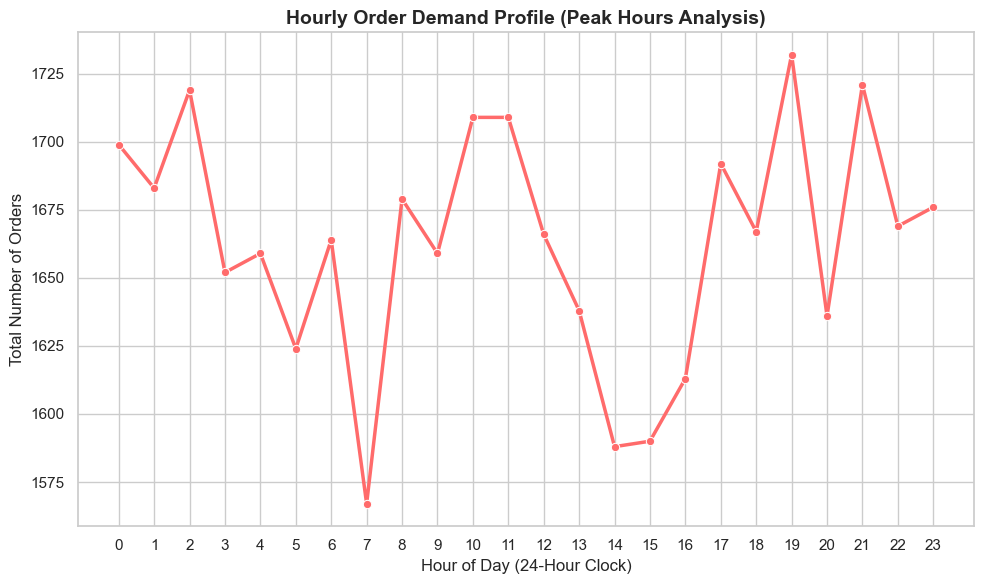

In [4]:
hourly_orders = df.groupby('Order_Hour').size().reset_index(name='Total_Orders')
sns.lineplot(data=hourly_orders, x='Order_Hour', y='Total_Orders', marker='o', color='#FF6B6B', linewidth=2.5)
plt.title('Hourly Order Demand Profile (Peak Hours Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (24-Hour Clock)', fontsize=12)
plt.ylabel('Total Number of Orders', fontsize=12)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [5]:
platform_metrics = df.groupby('Platform').agg(
    Avg_Delivery_Time=('Delivery Time (Minutes)', 'mean'),
    Avg_Rating=('Service Rating', 'mean'),
    SLA_Breach_Rate=('SLA_Breach', 'mean'),
    Refund_Rate=('Refund Requested', lambda x: (x == 'Yes').mean() * 100)
).reset_index()

print("--- PLATFORM PERFORMANCE BREAKDOWN ---")
print(platform_metrics.round(2))

--- PLATFORM PERFORMANCE BREAKDOWN ---
           Platform  Avg_Delivery_Time  Avg_Rating  SLA_Breach_Rate  \
0           Blinkit              29.50        3.24             0.92   
1           JioMart              29.60        3.26             0.92   
2  Swiggy Instamart              29.48        3.23             0.92   

   Refund_Rate  
0        45.93  
1        45.40  
2        45.90  


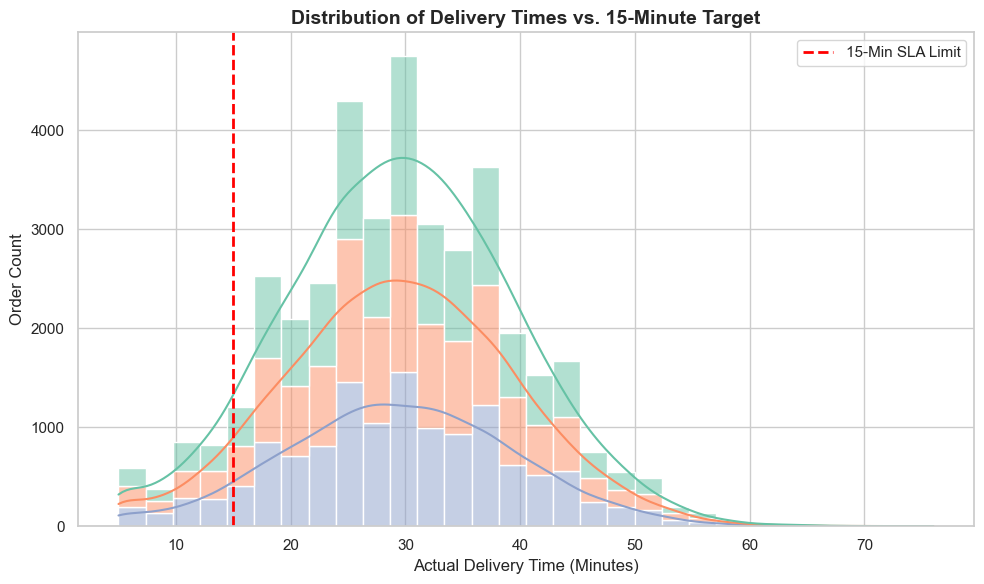

In [6]:
sns.histplot(data=df, x='Delivery Time (Minutes)', hue='Platform', kde=True, bins=30, multiple='stack', palette='Set2')
plt.axvline(x=15, color='red', linestyle='--', linewidth=2, label='15-Min SLA Limit')
plt.title('Distribution of Delivery Times vs. 15-Minute Target', fontsize=14, fontweight='bold')
plt.xlabel('Actual Delivery Time (Minutes)', fontsize=12)
plt.ylabel('Order Count', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_19336\598286204.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_revenue, x='Order Value (INR)', y='Product Category', palette='Blues_r')


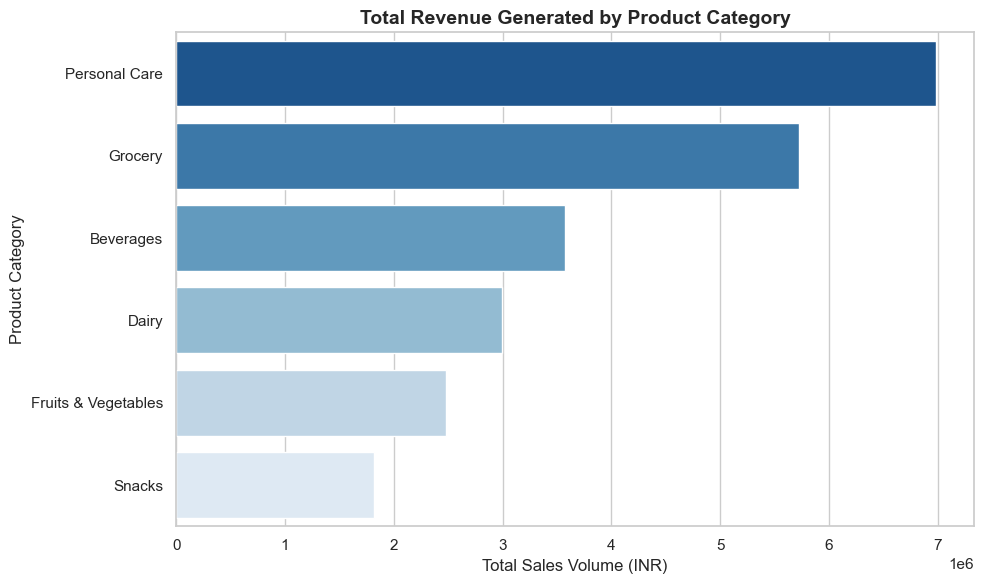

In [7]:
category_revenue = df.groupby('Product Category')['Order Value (INR)'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=category_revenue, x='Order Value (INR)', y='Product Category', palette='Blues_r')
plt.title('Total Revenue Generated by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales Volume (INR)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.tight_layout()
plt.show()